intallations


In [1]:
!pip install torch torchvision matplotlib scikit-learn transformers

imports

In [2]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

drive + paths

In [3]:
from google.colab import drive
drive.mount('/content/drive')

base_dir = "/content/drive/MyDrive/genai_project/data/split"

train_dir = f"{base_dir}/train"
val_dir   = f"{base_dir}/val"
test_dir  = f"{base_dir}/test"

real_test_dir = "/content/drive/MyDrive/genai_project/data/real_test"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


transforms

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

datasets

In [5]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=test_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=test_transform)

real_dataset = datasets.ImageFolder(real_test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)
test_loader  = DataLoader(test_dataset, batch_size=16)
real_loader  = DataLoader(real_dataset, batch_size=16)

print("Classes:", train_dataset.classes)

Classes: ['clean', 'empty', 'finished_leftovers', 'full']


model

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(train_dataset.classes))
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


loss + optimizer

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

train + eval

In [8]:
def train_epoch(model, loader):
    model.train()
    correct = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        correct += (outputs.argmax(1) == y).sum().item()

    return correct / len(loader.dataset)


def eval_model(model, loader):
    model.eval()
    correct = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)

            correct += (outputs.argmax(1) == y).sum().item()

    return correct / len(loader.dataset)

training

In [9]:
epochs = 10

for epoch in range(epochs):
    train_acc = train_epoch(model, train_loader)
    val_acc   = eval_model(model, val_loader)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Acc: {train_acc:.3f}")
    print(f"Val Acc:   {val_acc:.3f}")


Epoch 1
Train Acc: 0.327
Val Acc:   0.375

Epoch 2
Train Acc: 0.668
Val Acc:   0.400

Epoch 3
Train Acc: 0.796
Val Acc:   0.425

Epoch 4
Train Acc: 0.862
Val Acc:   0.450

Epoch 5
Train Acc: 0.923
Val Acc:   0.450

Epoch 6
Train Acc: 0.974
Val Acc:   0.375

Epoch 7
Train Acc: 0.969
Val Acc:   0.350

Epoch 8
Train Acc: 0.990
Val Acc:   0.375

Epoch 9
Train Acc: 0.980
Val Acc:   0.325

Epoch 10
Train Acc: 0.974
Val Acc:   0.375


Synthetic Test

In [10]:
synthetic_acc = eval_model(model, test_loader)
print(f"\n🧪 Synthetic Test Accuracy: {synthetic_acc:.3f}")


🧪 Synthetic Test Accuracy: 0.364


Real Test

In [11]:
real_acc = eval_model(model, real_loader)
print(f"\n🔥 Real Test Accuracy: {real_acc:.3f}")


🔥 Real Test Accuracy: 0.523


Confusion Matrix - function

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x)
            preds = outputs.argmax(1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    return np.array(all_labels), np.array(all_preds)

Synthetic CM

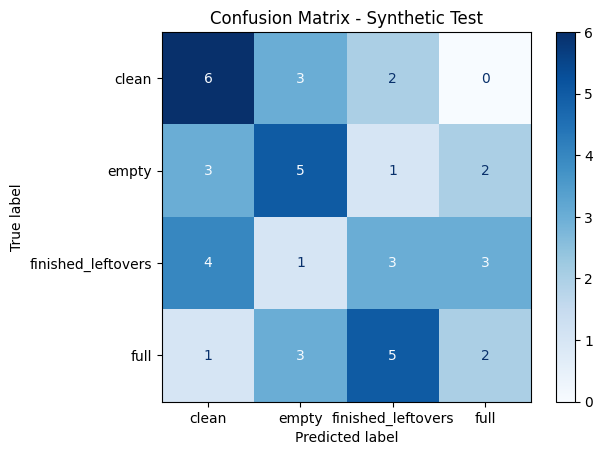

In [13]:
y_true, y_pred = get_predictions(model, test_loader)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Synthetic Test")
plt.show()

Real CM

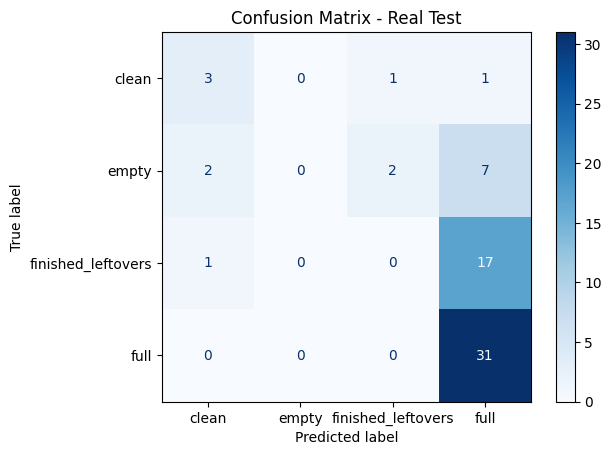

In [14]:
y_true, y_pred = get_predictions(model, real_loader)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=real_dataset.classes
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Real Test")
plt.show()

CLIP (on real data only)

In [15]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

labels_text = [
    "a clean empty plate",
    "an empty plate with crumbs and stains",
    "a plate with a few leftover bites of food",
    "a full plate of food",
    # "an unrecognizable plate with noise or distortion"
]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP eval

In [16]:
def clip_predict(image):
    inputs = processor(
        text=labels_text,
        images=image,
        return_tensors="pt",
        padding=True
    ).to(device)

    outputs = clip_model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=1)

    return probs.argmax().item()


def evaluate_clip(loader):
    correct = 0
    total = 0

    for x, y in loader:
        for i in range(len(x)):
            image = transforms.ToPILImage()(x[i])
            pred = clip_predict(image)

            if pred == y[i].item():
                correct += 1

            total += 1

    return correct / total


clip_acc = evaluate_clip(real_loader)

print(f"\n🤖 CLIP Accuracy (REAL DATA): {clip_acc:.3f}")


🤖 CLIP Accuracy (REAL DATA): 0.246
